# Experiment Analysis
Automated analysis generated by Stage 06.


In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Configure seaborn styling
sns.set_theme(style="whitegrid")

# Load flattened data
DATA_PATH = Path("../input/experiment_6_results_flat.csv")
df = pd.read_csv(DATA_PATH)

print(f"Loaded {len(df)} records.")
df.head()


Loaded 1782 records.


,runtimes,deletion_ratio,marginals_error,tvd_2way,ml_accuracy,violations,loss_function,marginal_generation_quality,marginal_selection_quality,dataset_name,...,ml_acc_repaired,ml_acc_synthetic,ml_acc_logistic_regression_repaired,ml_acc_logistic_regression_synthetic,ml_acc_random_forest_repaired,ml_acc_random_forest_synthetic,ml_acc_mlp_repaired,ml_acc_mlp_synthetic,loss_marginal_repaired,loss_marginal_synthetic
0,{'repair': 3181.932707309723},0.07890,"{'synthetic_avg': 0.8197275936491971, 'repaire...","{'synthetic_avg': 0.046196844191474545, 'repai...",{'synthetic': {'logistic_regression': 0.823962...,"{'private': 0, 'synthetic': 35396875, 'repaire...","{'synthetic': {'total': 0.07823273150790847, '...",{'avg_relative_error': 0.31503496698155636},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",adult_loaded_adult_aim_eps0.3_syn_repaired,...,0.835661,0.835183,0.826010,0.823963,0.839134,0.83895,0.841837,0.842635,0.180415,0.180175
1,{'repair': 3238.872866630554},0.07890,"{'synthetic_avg': 0.8197275975957495, 'repaire...","{'synthetic_avg': 0.046196844191474545, 'repai...",{'synthetic': {'logistic_regression': 0.823962...,"{'private': 0, 'synthetic': 35396875, 'repaire...","{'synthetic': {'total': 0.07823273150790847, '...",{'avg_relative_error': 0.31503496698155636},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",adult_loaded_adult_aim_eps0.3_syn_repaired,...,0.835654,0.835183,0.826010,0.823963,0.839114,0.83895,0.841837,0.842635,0.180415,0.180175
2,{'repair': 9692.801965475082},0.14924,"{'synthetic_avg': 0.8197275936491971, 'repaire...","{'synthetic_avg': 0.046196844191474545, 'repai...",{'synthetic': {'logistic_regression': 0.823962...,"{'private': 0, 'synthetic': 35396875, 'repaire...","{'synthetic': {'total': 0.07823273150790847, '...",{'avg_relative_error': 0.31503496698155636},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",adult_loaded_adult_aim_eps0.3_syn_repaired,...,0.834978,0.835183,0.826256,0.823963,0.838930,0.83895,0.839749,0.842635,0.180398,0.180175
3,{'repair': 3339.968957424164},0.07890,"{'synthetic_avg': 0.8197275975957495, 'repaire...","{'synthetic_avg': 0.046196844191474545, 'repai...",{'synthetic': {'logistic_regression': 0.823962...,"{'private': 0, 'synthetic': 35396875, 'repaire...","{'synthetic': {'total': 0.07823273150790847, '...",{'avg_relative_error': 0.31503496698155636},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",adult_loaded_adult_aim_eps0.3_syn_repaired,...,0.835654,0.835183,0.826010,0.823963,0.839114,0.83895,0.841837,0.842635,0.180415,0.180175
4,{'repair': 3329.2060174942017},0.07890,"{'synthetic_avg': 0.8197275936491971, 'repaire...","{'synthetic_avg': 0.046196844191474545, 'repai...",{'synthetic': {'logistic_regression': 0.823962...,"{'private': 0, 'synthetic': 35396875, 'repaire...","{'synthetic': {'total': 0.07823273150790847, '...",{'avg_relative_error': 0.31503496698155636},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",adult_loaded_adult_aim_eps0.3_syn_repaired,...,0.835654,0.835183,0.826010,0.823963,0.839114,0.83895,0.841837,0.842635,0.180415,0.180175


## 1. Deletion Ratio by Dataset
Analyzes the deletion ratio trends using line plots for each dataset.


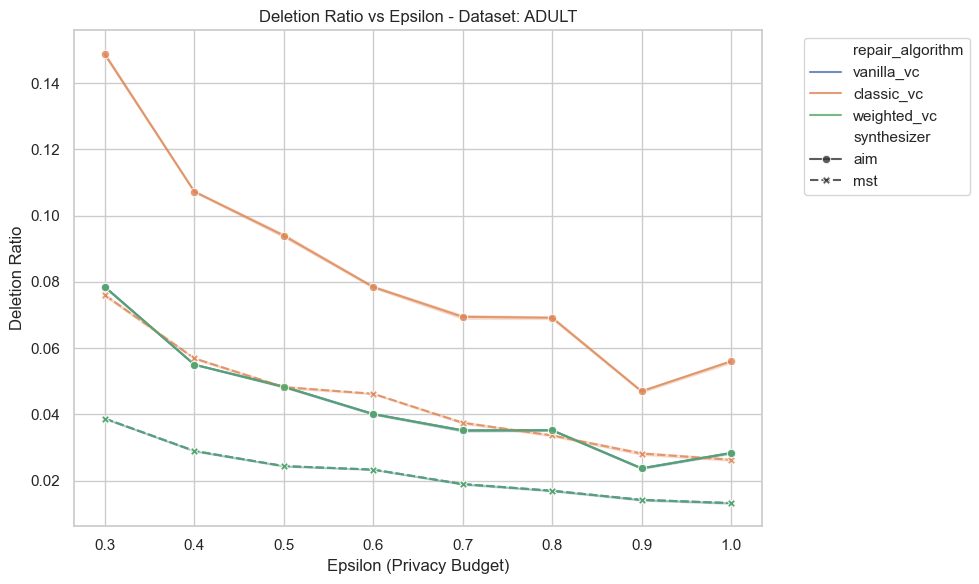

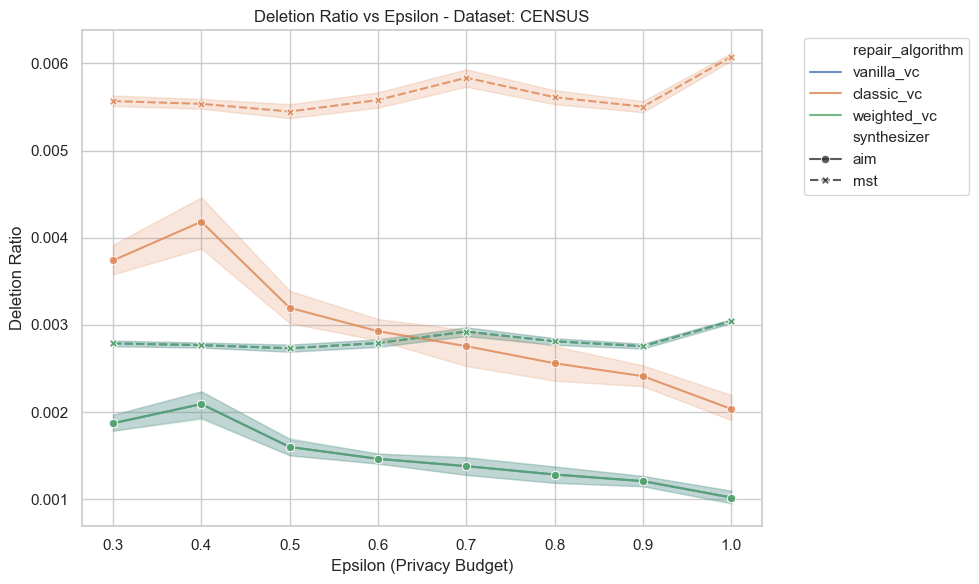

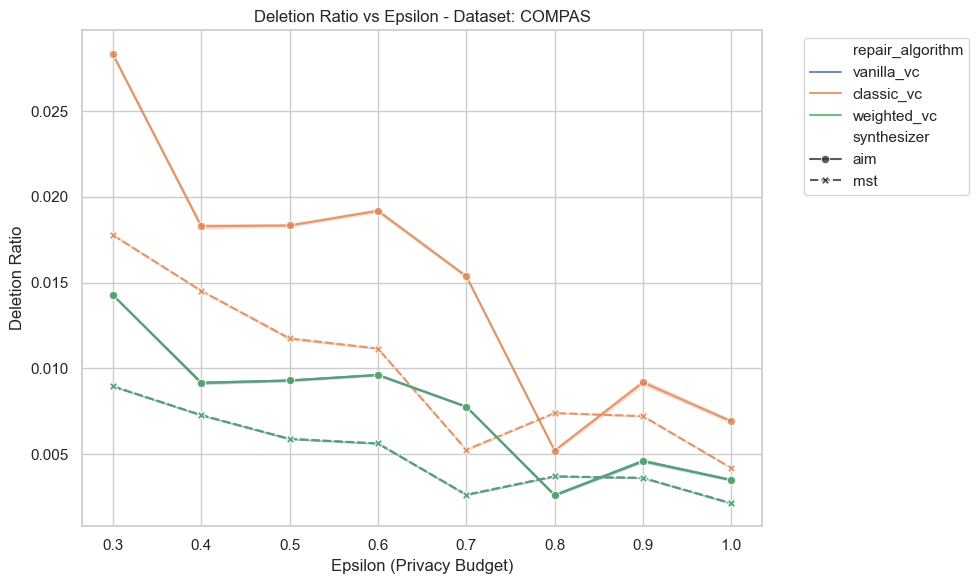

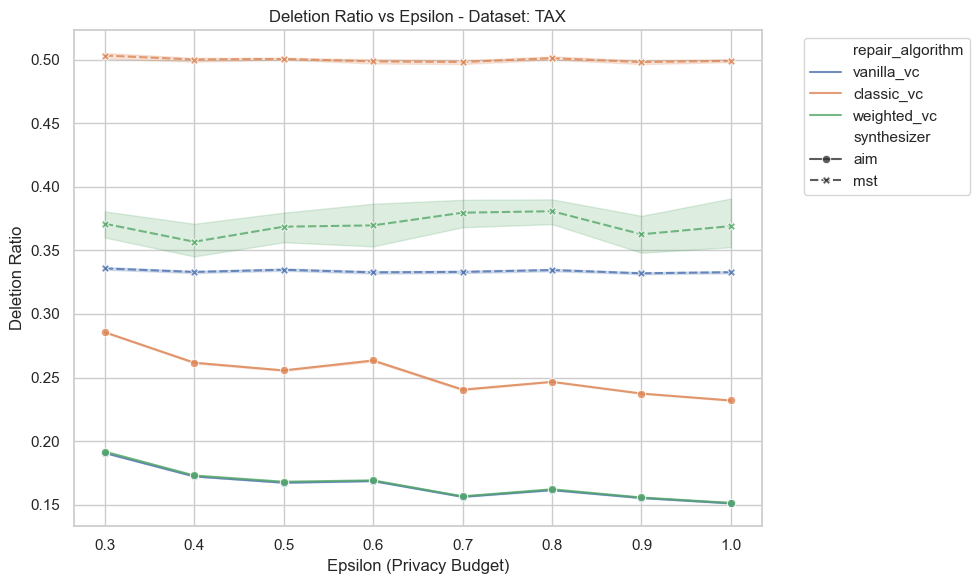

In [36]:
datasets = df['dataset'].unique()

for dataset in datasets:
    plt.figure(figsize=(10, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="deletion_ratio", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True,
        err_style="band",
        alpha=0.8
    )
    
    plt.title(f"Deletion Ratio vs Epsilon - Dataset: {dataset.upper()}")
    plt.ylabel("Deletion Ratio")
    plt.xlabel("Epsilon (Privacy Budget)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 2. Marginals Error
Comparative analysis of marginals error after repair.


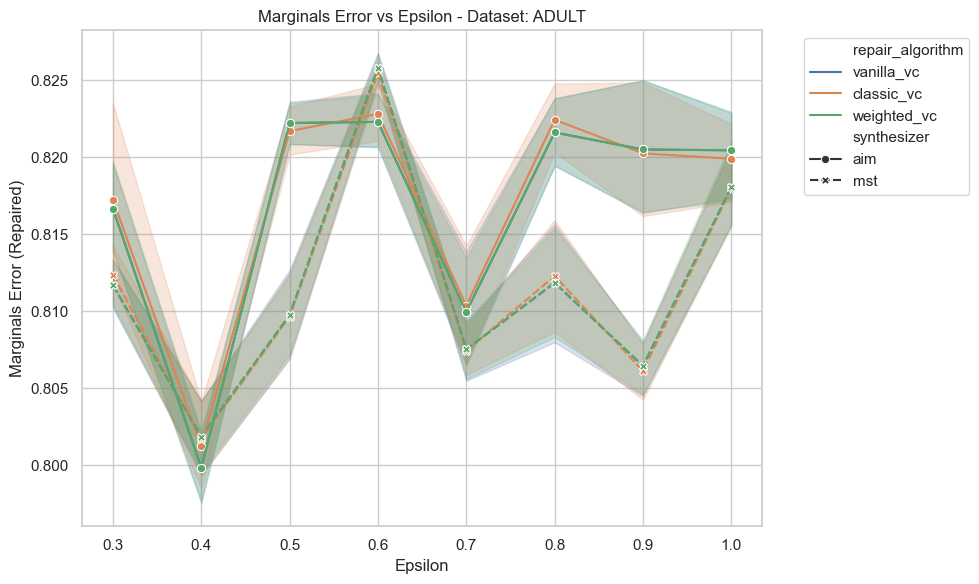

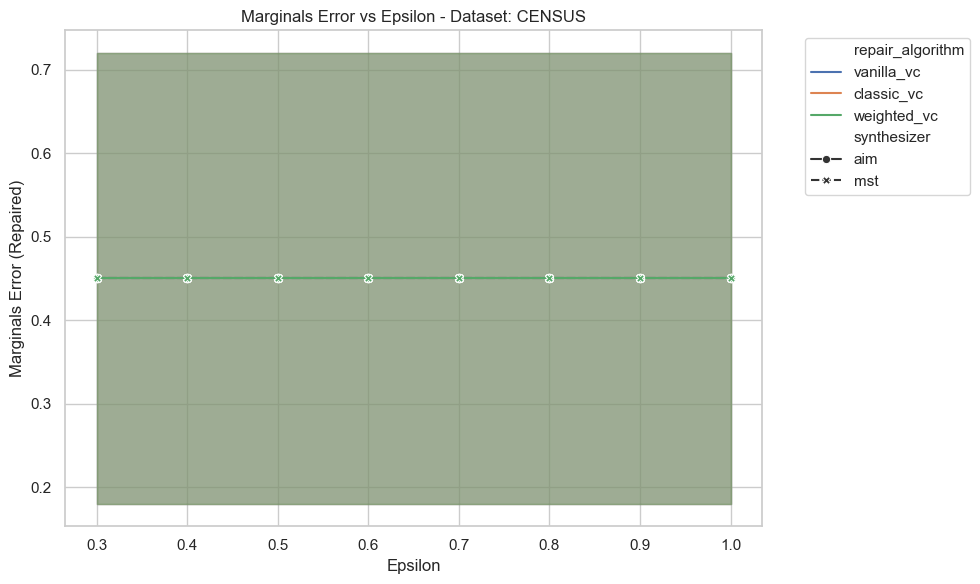

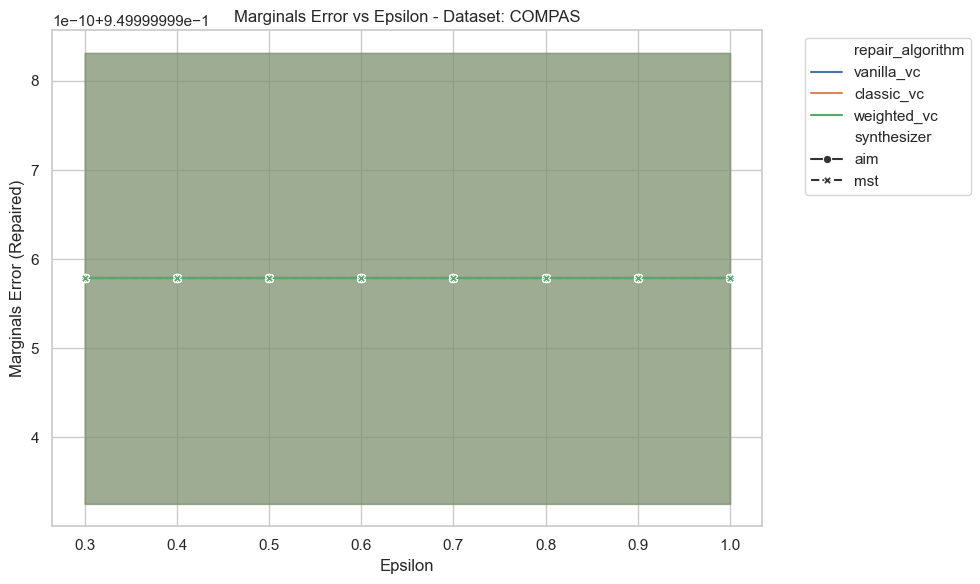

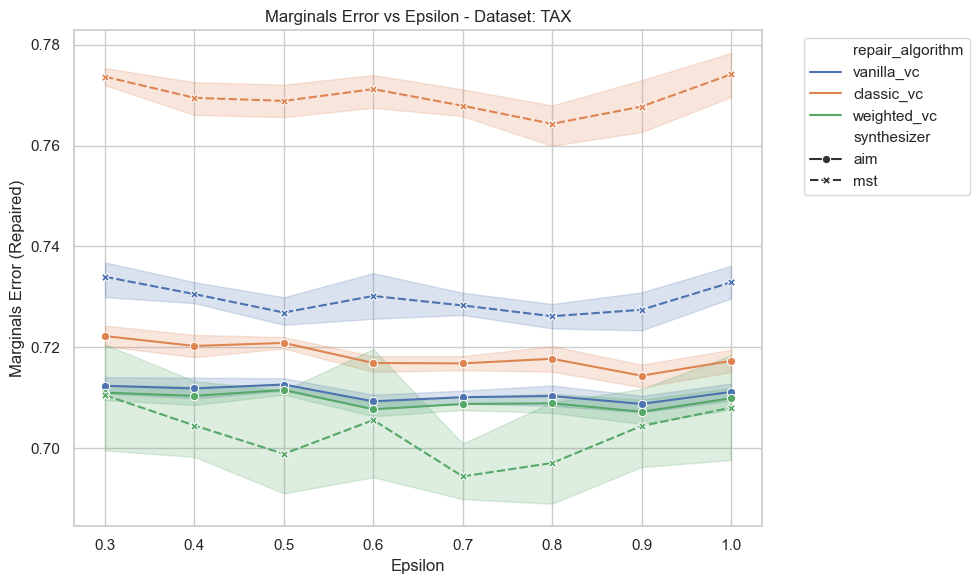

In [37]:
for dataset in datasets:
    plt.figure(figsize=(10, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="marginals_error_repaired", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True,
        err_style="band"
    )
    
    plt.title(f"Marginals Error vs Epsilon - Dataset: {dataset.upper()}")
    plt.ylabel("Marginals Error (Repaired)")
    plt.xlabel("Epsilon")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 3. Marginals Loss


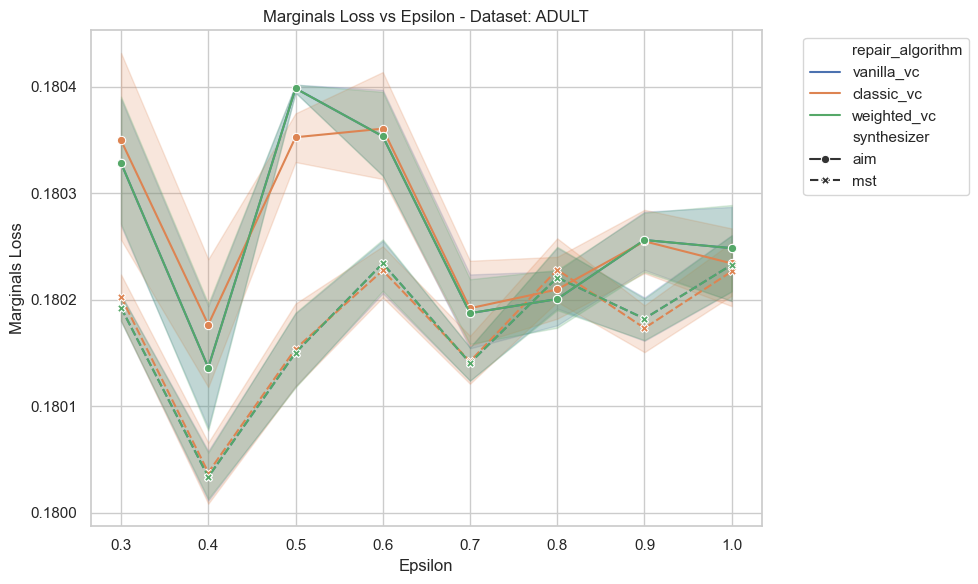

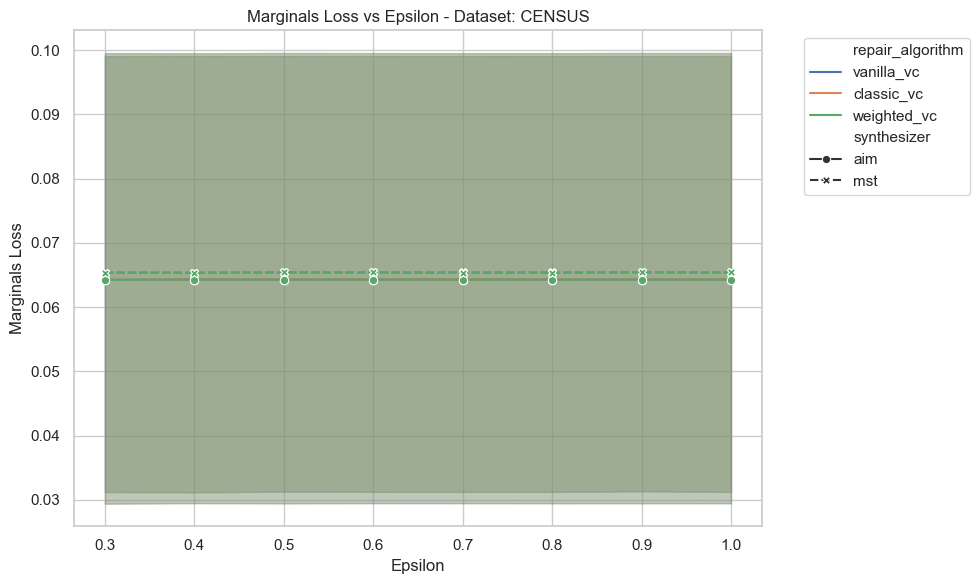

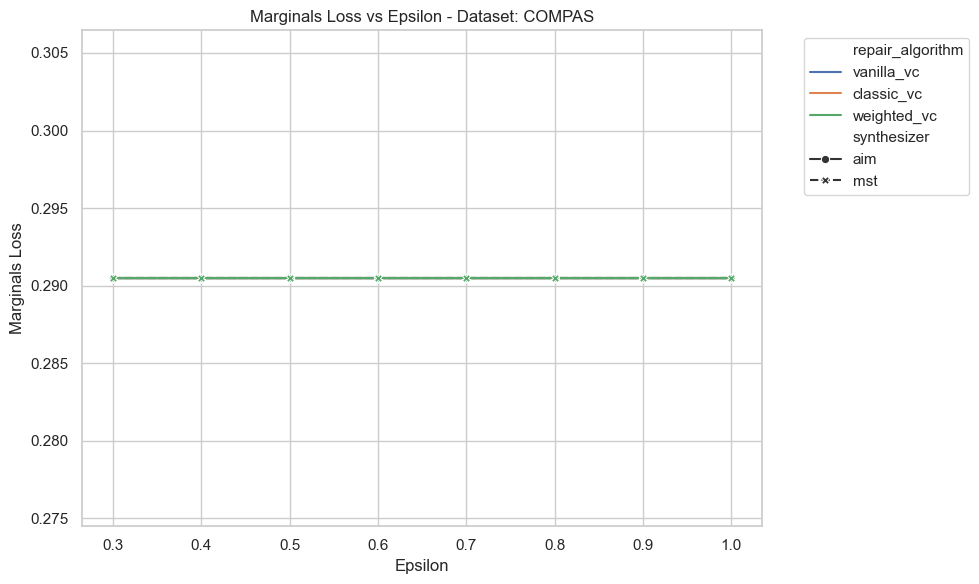

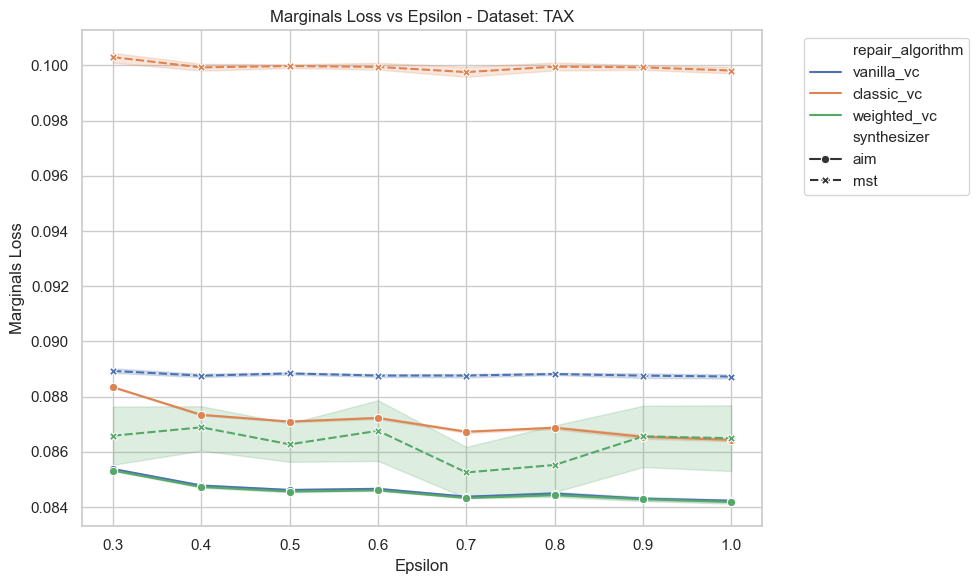

In [38]:
for dataset in datasets:
    plt.figure(figsize=(10, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="loss_marginal_repaired", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True
    )
    
    plt.title(f"Marginals Loss vs Epsilon - Dataset: {dataset.upper()}")
    plt.ylabel("Marginals Loss")
    plt.xlabel("Epsilon")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 4. Total Variation Distance (TVD)


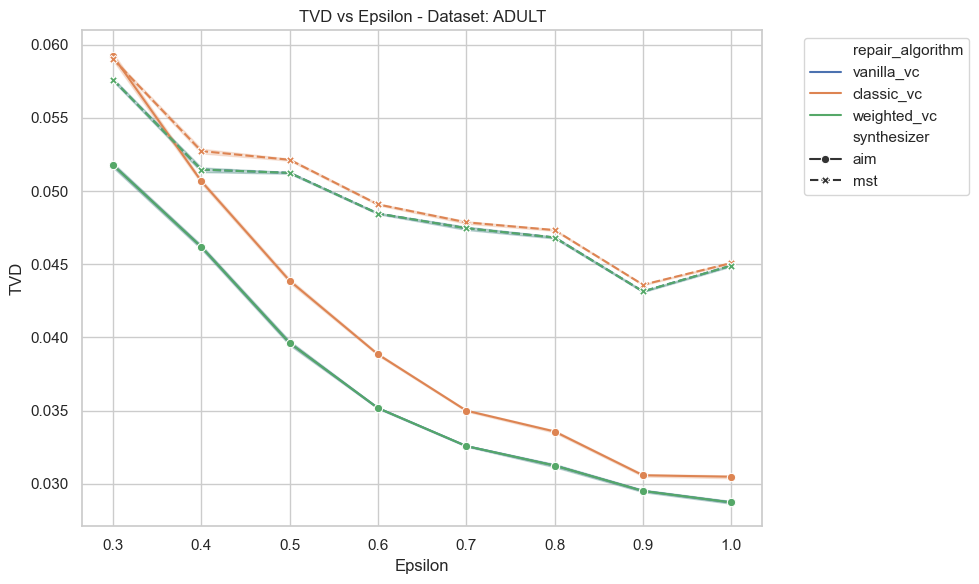

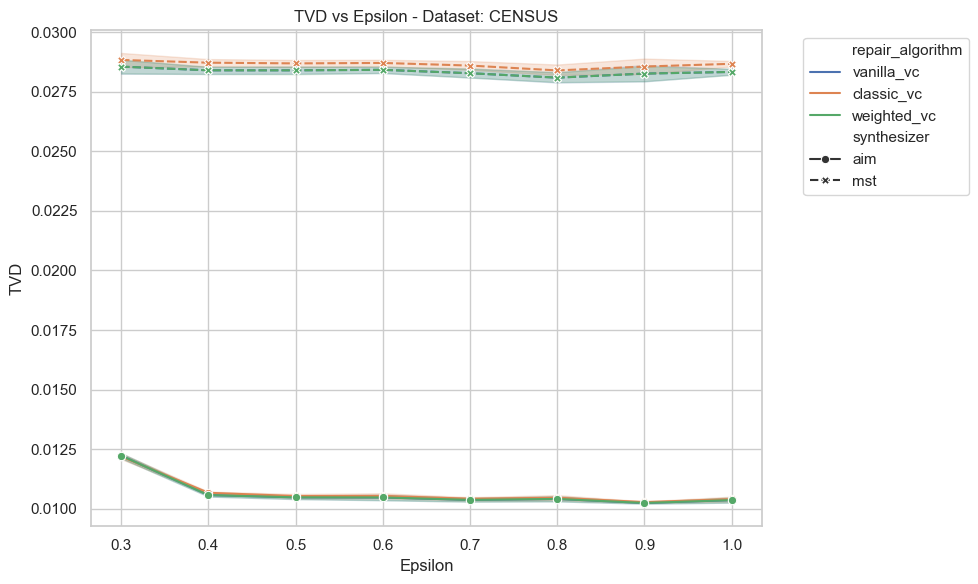

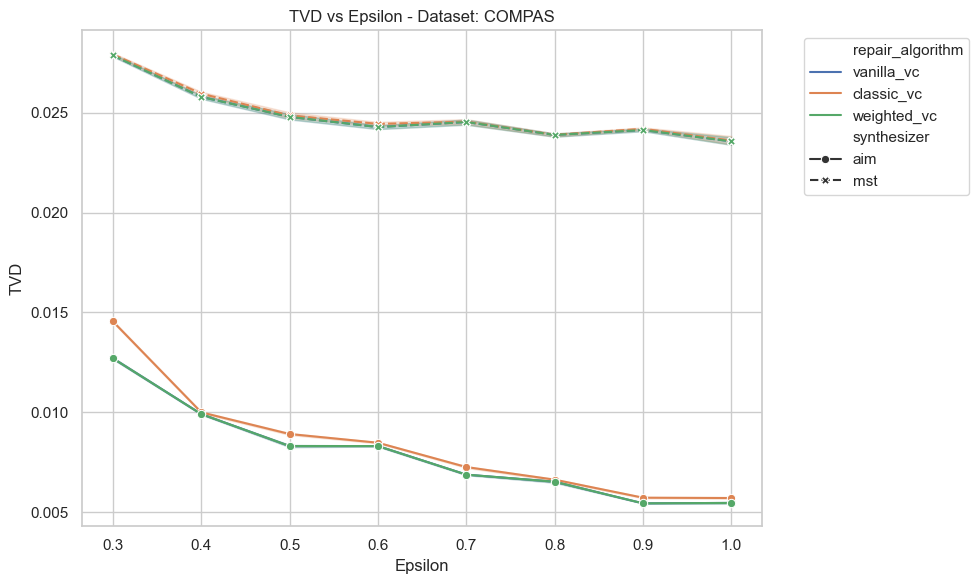

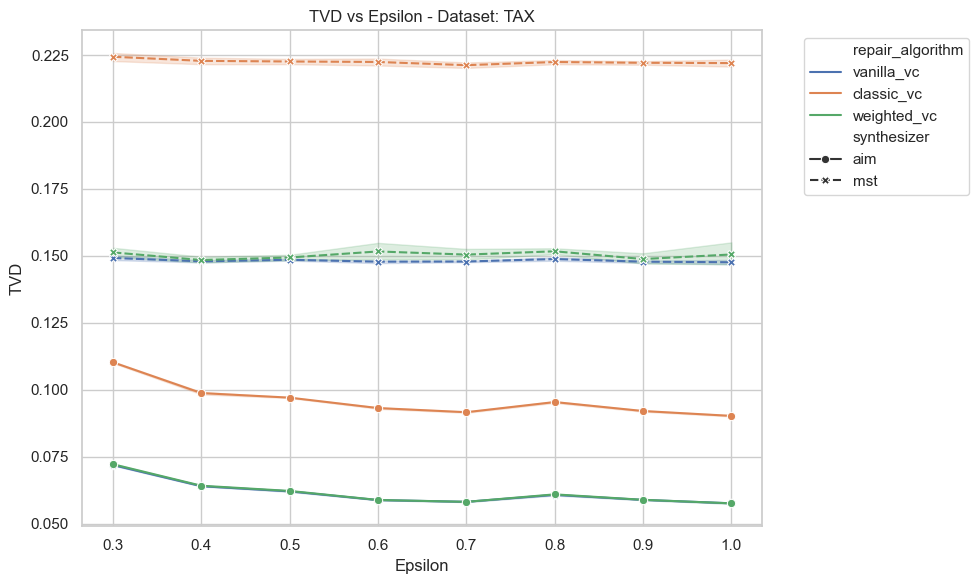

In [39]:
for dataset in datasets:
    plt.figure(figsize=(10, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="tvd_repaired", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True
    )
    
    plt.title(f"TVD vs Epsilon - Dataset: {dataset.upper()}")
    plt.ylabel("TVD")
    plt.xlabel("Epsilon")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 5. Machine Learning Accuracy


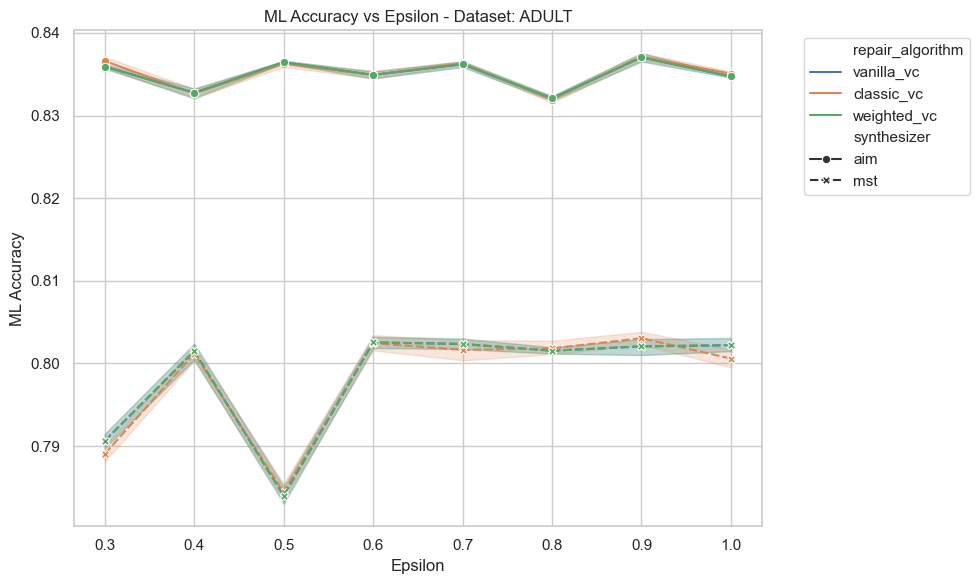

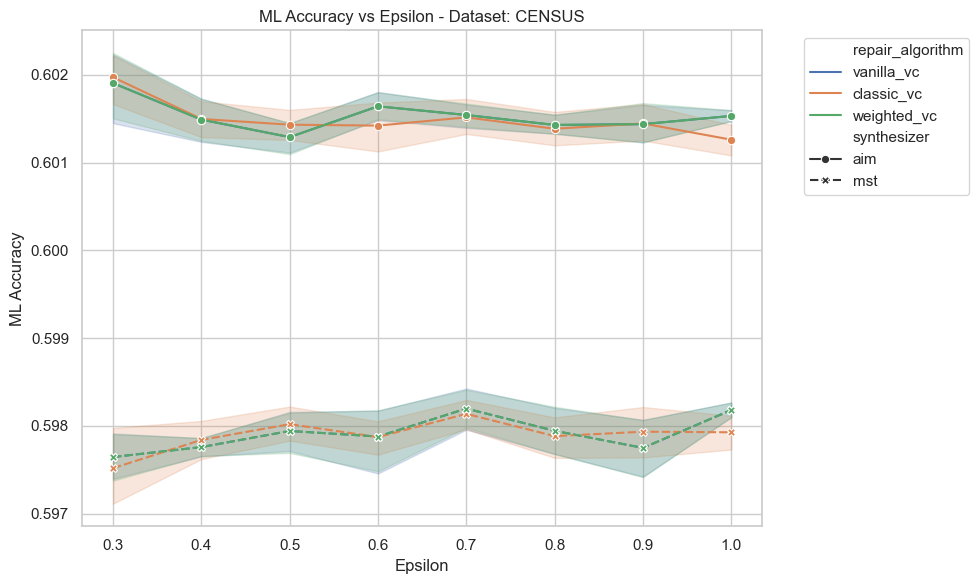

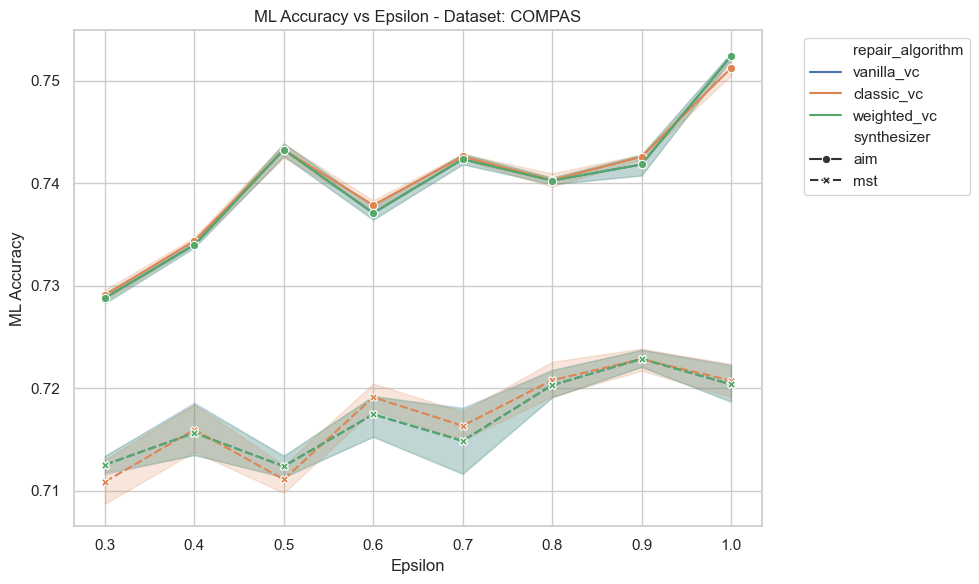

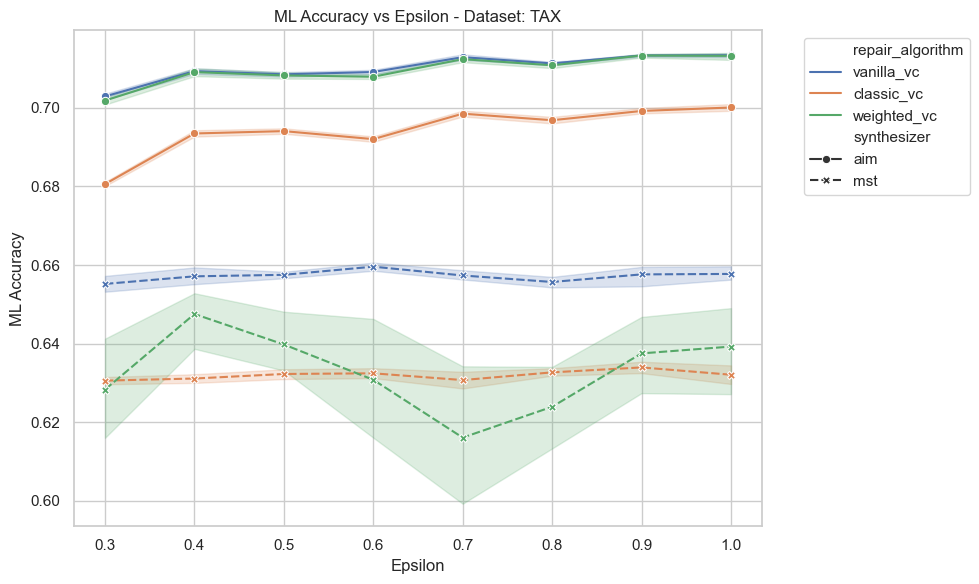

In [40]:
for dataset in datasets:
    plt.figure(figsize=(10, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="ml_acc_repaired", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True
    )
    
    plt.title(f"ML Accuracy vs Epsilon - Dataset: {dataset.upper()}")
    plt.ylabel("ML Accuracy")
    plt.xlabel("Epsilon")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 6. Runtime


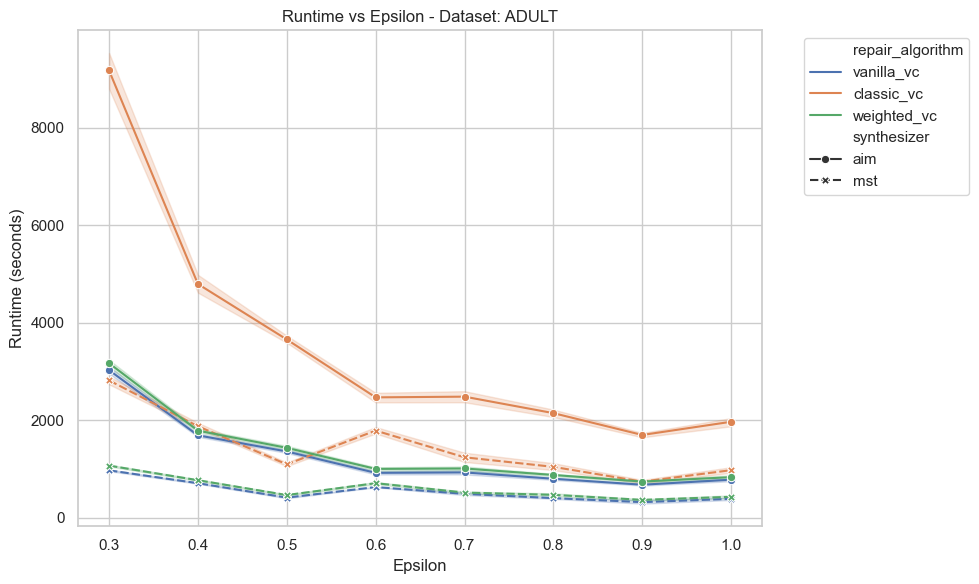

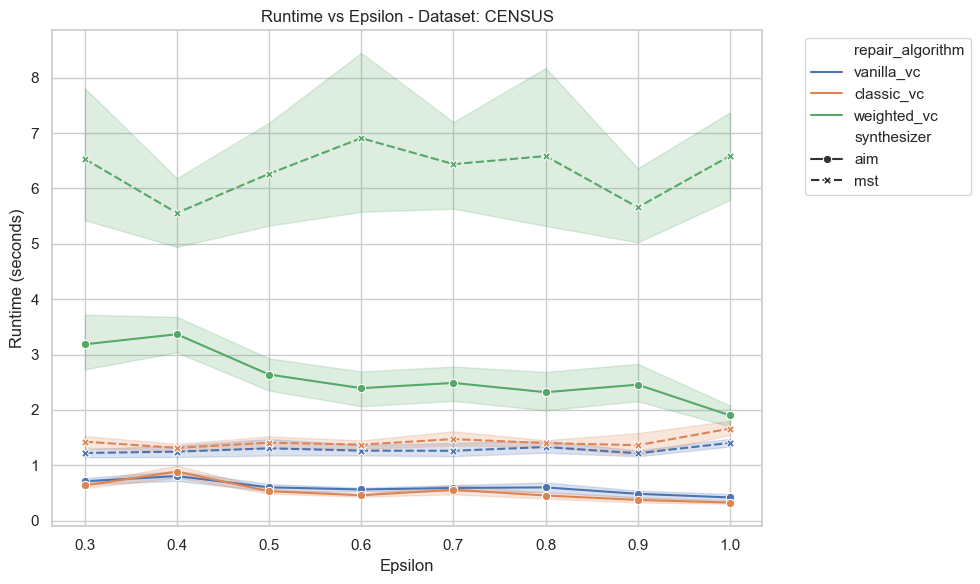

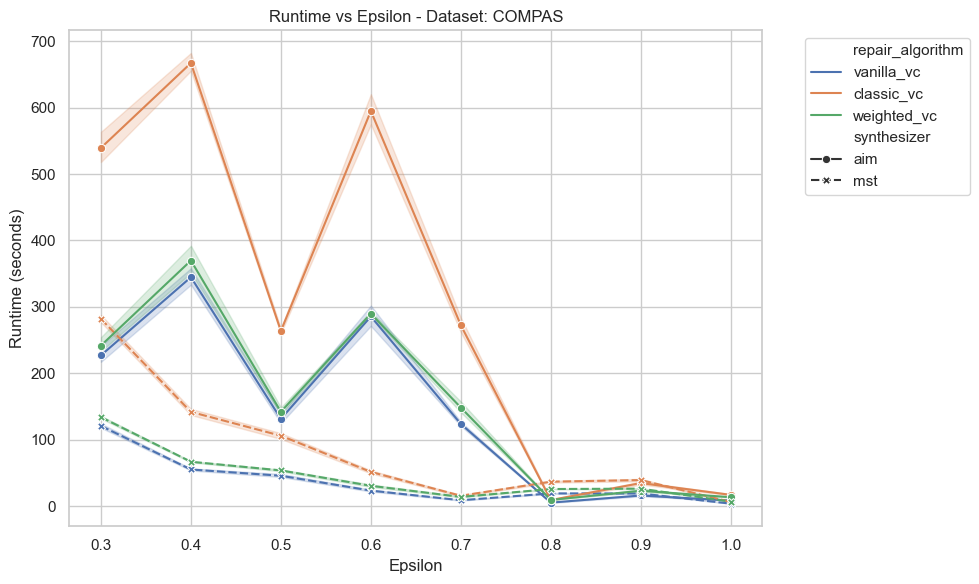

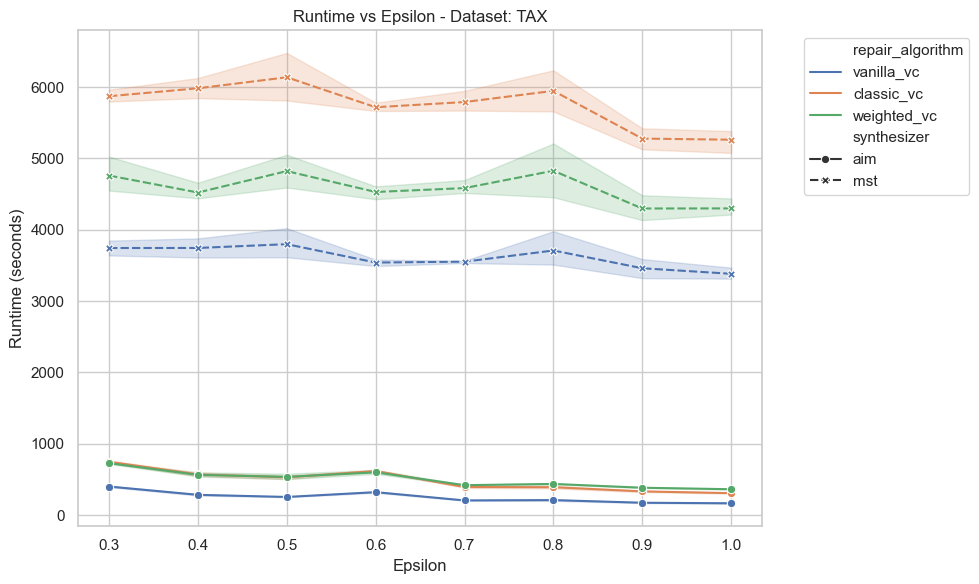

In [41]:
for dataset in datasets:
    plt.figure(figsize=(10, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="repair_runtime", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True
    )
    
    plt.title(f"Runtime vs Epsilon - Dataset: {dataset.upper()}")
    plt.ylabel("Runtime (seconds)")
    plt.xlabel("Epsilon")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
